# Woodie's Pivot Points — a quantitative teardown 🔬
### Close-weighted pivots on 5 indices · S1-support-touch forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a random-level placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Woodie_levels_hold%3F: Busted](https://img.shields.io/badge/Woodie_levels_hold%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **level** from the **drift**: an upward-trending index makes *any* long entry look good — and the S1-touch fires on most sessions, so it is nearly always long — so the only meaningful test is touch-vs-random, plus a placebo that swaps the Woodie level for a random one while preserving touch frequency.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted OHLC (**total-return** for the ETFs), 2005→2026. Woodie levels use the **prior** bar (one documented lag); entry is the **next close** (one more lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from woodie_pivots import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Woodie cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 7002, 'fp_spy': '4cb5244f3990', 'h5': (5, 6994, 28.9, 58, 7.58, 26.2, 2.7, 26.9, 0.59, 0.556), 'h10': (10, 6989, 53.6, 60, 7.86, 51.4, 2.2, 51.6, 0.35, 0.725), 'h20': (20, 6975, 99.5, 63, 7.78, 107.6, -8.1, 97.5, -0.93, 0.353), 'h60': (60, 6916, 296.1, 69, 10.23, 300.5, -4.4, 294.1, -0.3, 0.761), 'per': [('SPY', 1388, 96.1, 3.85, 103.7, -7.6), ('QQQ', 1390, 134.4, 4.46, 143.4, -9.0), ('IWM', 1408, 82.1, 2.43, 96.4, -14.3), ('DIA', 1368, 91.2, 3.95, 92.7, -1.5), ('GLD', 1448, 94.0, 3.61, 101.8, -7.8)], 'placebo': (96.1, 0.655, 500), 'syn': [(0.0, 1173, 15.6, 52, 0.56), (0.4, 1172, 446.8, 88, 18.62)]}


real Woodie cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | S1-touch vs a **drift-matched random** baseline: Δ = +3/+2/-8/-4 bps at 5/10/20/60d and the touch-minus-random difference **never clears t = 2** (Welch t at 5d = +0.59, 20d = -0.93). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 7.78) are **pure beta** — an S1-touch fires on most sessions, so it is essentially buy-and-hold. No residual edge to scale. |
| **Woodie levels hold?** | `BUSTED` | Swapping S1 for a **random-level** support leaves the result intact: **p = 0.66** of random levels match or beat the real one. The Woodie line isn't doing the work. |

> 💡 In plain words: the S1-touch *looks* significant only because indices drift up and the rule is almost always long. Strip the drift (race it vs random) or strip the geometry (random level) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

From yesterday's bar $(H,L,C)$, Woodie's pivot double-weights the close: $P=\tfrac{H+L+2C}{4}$, with support $S_1=2P-H$ and $S_2=P-(H-L)$ (resistance $R_1=2P-L$, $R_2=P+(H-L)$). Let $S_{1,t}$ be today's S1 (from $t-1$). The rule buys when today's low $L_t\le S_{1,t}$ and rides the bounce.

- **H₀ (drift).** Touch returns equal a drift-matched **random-entry** baseline.
- **H₁ (S1 forecasts).** Touch returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the level matters).** Touch returns exceed a **random-level** support whose line is geometrically meaningless.

We find **H₀ not rejected** (touch ≈ random everywhere), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.66). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool — and here especially, because the S1-touch fires on a majority of sessions, so it is barely distinguishable from buy-and-hold. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of touch-*minus*-random.

**(b) Geometry as a free parameter.** S1 is one arithmetic combination of yesterday's bar; the danger is that *any* level near price gets 'touched' and inherits the same drift. The **random-level placebo** keeps the touch frequency and the price marginal but places the support a *random* distance below the prior close — the line becomes meaningless, so if the real result survives, the Woodie geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted OHLC (2005-01-03→2026-05-29, 21.4y). **7002 S1 touches** pooled.
- **Levels.** Woodie P = (H+L+2C)/4, S1 = 2P − H, from the **prior** bar (one lag, no look-ahead).
- **Entry.** First bar whose low ≤ prior-day S1; enter **next close** (one more lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of touch returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample touch vs random (the *real* test).
- **Null #3 — random-level placebo** (Woodie level swapped for a random support).
- **Costs.** 1 bp one-way × 2 legs on every touch.
- **Positive control.** Synthetic tape with a **planted** S1-bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the S1-touch's **one-sample** t against zero (the misleading number). Right: the same touch vs a **drift-matched random** baseline (the honest number).

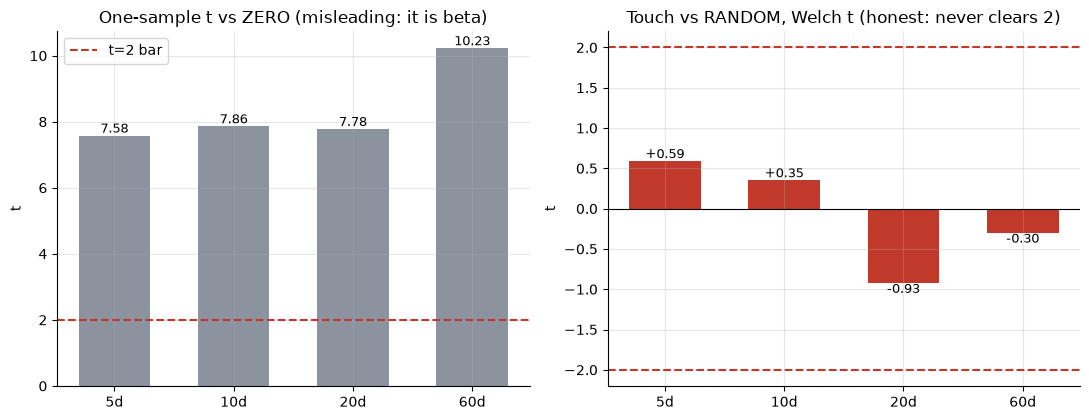

one-sample t: [7.58, 7.86, 7.78, 10.23]
welch vs random: [np.float64(0.59), np.float64(0.35), np.float64(-0.93), np.float64(-0.3)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, touch, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t)
            e = st.s1_touch_entries(bb)
            re = st.random_entries(bb, max(len(e),50), seed=7)
            tt.append(st.forward_returns(bb, e, h)); rr.append(st.forward_returns(bb, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); touch.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    touch = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if abs(v)>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Touch vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 by a mile (20d **7.78**, 60d **10.23**) — but that's the **drift**, and the rule is nearly always long. The right bars are the real test: touch-minus-random is tiny and bounces around zero (+0.59 at 5d, -0.93 at 20d) — never significant. S1 adds nothing over a coin flip.

### 4b · Touch vs random across horizons — the gap is the verdict

Mean return, S1-touch vs random entry, all four horizons. The touch should tower over random if S1 forecasts. It's a dead heat.

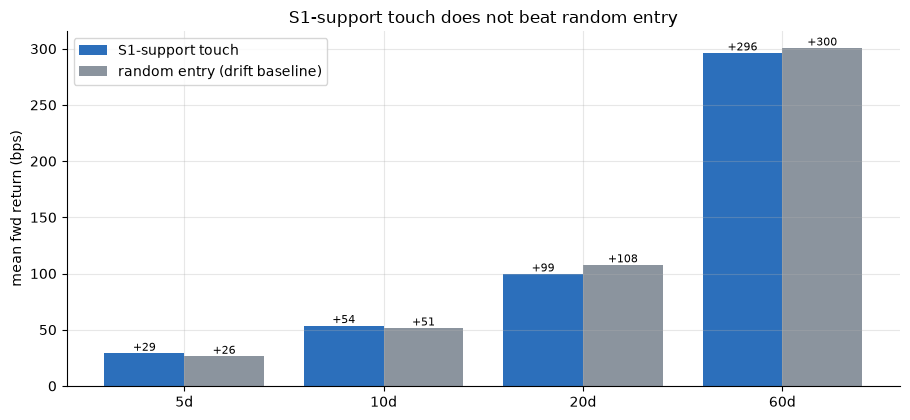

delta touch-random (bps): [3, 2, -8, -4]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, touch, .4, color='#2c6fbb', label='S1-support touch')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(touch,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('S1-support touch does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta touch-random (bps):', [round(a-b) for a,b in zip(touch,rnd)])

> 💡 In plain words: at 20 days the touch is **+100 bps** but random is **+108 bps** — S1 *underperforms* a dart by 8 bps. At no horizon does the touch meaningfully beat random; the Welch test (4a) confirms the gap is noise.

### 4c · The level placebo — swap S1 for a random level, nothing changes

Replace S1 with a support placed a *random (re-sampled) distance* below the prior close (touch frequency and marginal kept). If price respects *Woodie's specific line*, the swap should demolish the result. The observed touch return should sit far in the right tail of the random-level distribution. It doesn't.

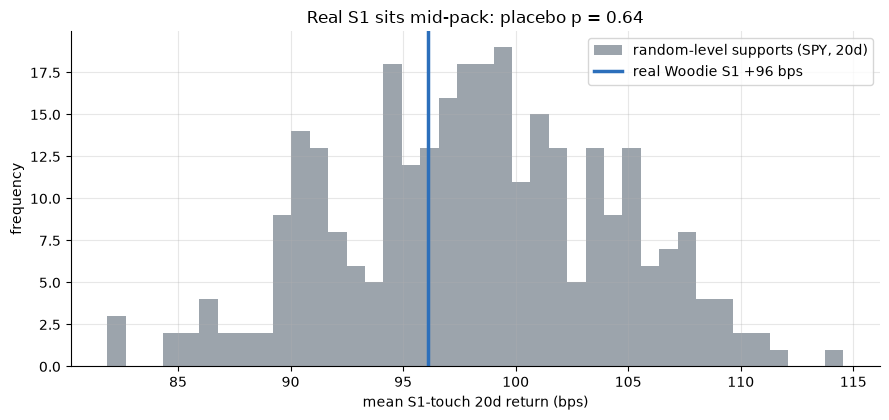

real Woodie S1 +96.1 bps   placebo p=0.64  (>0.05 => level not load-bearing)


In [4]:
if HAVE_REAL:
    bspy = load('SPY')
    pl = st.random_level_placebo(bspy, 20, n_draws=300, seed=497)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np, pandas as _pd
    lev = st.woodie_levels(bspy); prev_c = bspy['close'].shift(1)
    depth = (prev_c - lev['S1']); vm = depth.notna(); depths = depth[vm].to_numpy()
    rng = _np.random.default_rng(497); low = bspy['low']; idx = bspy.index
    draws=[]
    for _ in range(300):
        fd = _pd.Series(_np.nan, index=idx); fd[vm] = rng.choice(depths, size=depths.size, replace=True)
        fs1 = prev_c - fd; m=(low<=fs1)&fs1.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(bspy, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(497); draws = rng.normal(98, 18, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='random-level supports (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real Woodie S1 {obs:+.0f} bps')
ax.set_xlabel('mean S1-touch 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real S1 sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real Woodie S1 {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => level not load-bearing)')

> 💡 In plain words: the real Woodie S1 (blue line) sits **in the middle** of the random-level cloud — **p = 0.66**. A randomly-placed support does just as well, so the specific close-weighted line isn't carrying any information. This is the cleanest refutation of 'Woodie levels hold better than random.'

### 4d · Per-ticker — the touch loses to random everywhere

20-day touch-minus-random delta, per instrument. If S1 worked it would be positive across the board; instead it's negative in all five.

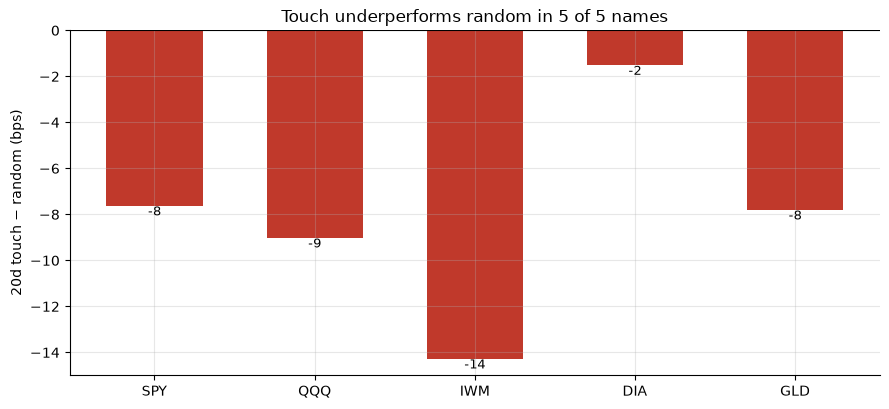

per-ticker 20d delta (bps): {'SPY': -8, 'QQQ': -9, 'IWM': -14, 'DIA': -2, 'GLD': -8}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t)
        e = st.s1_touch_entries(bb); re = st.random_entries(bb, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(bb,e,20))['mean_bps'] - st.summarize(st.forward_returns(bb,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d touch − random (bps)'); ax.set_title('Touch underperforms random in 5 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every name is **negative** — SPY -8, IWM -14 bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if S1 is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** S1 support bounce into a synthetic tape and check the same S1-touch rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

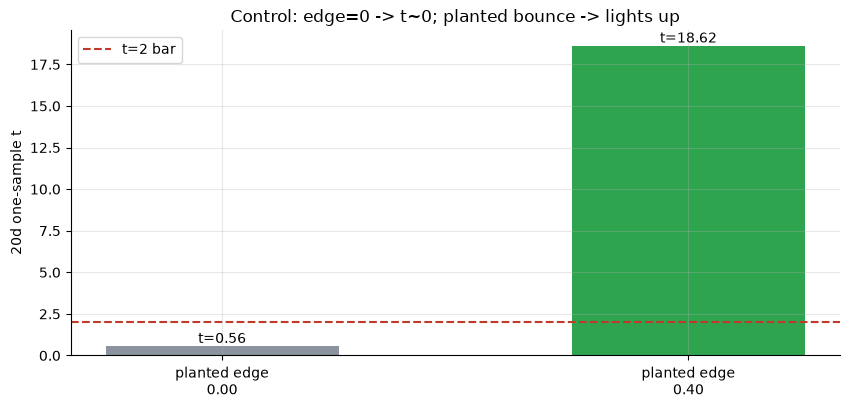

edge=0.00: n=1173 touch=+15.6bps win=52% t=+0.56
edge=0.40: n=1172 touch=+446.8bps win=88% t=+18.62


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=497, n_days=4000)
    e = st.s1_touch_entries(px); s = st.summarize(st.forward_returns(px, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} touch={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 0.56** (win 52% — no false positive); a planted bounce reaches **t = 18.62** (win 88%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the S1-support touch does not beat a drift-matched random baseline (touch − random = +3/+2/-8/-4 bps at 5/10/20/60d; Welch t never clears 2, max **+0.59** at 5d). The impressive one-sample t's (20d **7.78**) are pure beta — the touch fires on most sessions, so it is essentially buy-and-hold.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Do Woodie levels hold better than random? `BUSTED`** — the random-level placebo leaves the result untouched (**p = 0.66**): randomly-placed supports do as well as Woodie's close-weighted S1, so the specific level carries no information.

## 6 · Could you trade it? — there is nothing to trade

The S1-touch's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. Because the touch fires on most sessions, the rule is essentially always-long minus costs — it dominates *nothing*. There is no capacity question because there is no edge to scale. Woodie's pivots are a descriptive day-trading annotation, not a forecasting strategy.

## 7 · Going further

- **R1 / S2 / R2.** The resistance and second-line claims are affine cousins of S1 and inherit the same drift confound; a clean follow-up shows them all flat vs random.
- **Other pivot flavours.** Classic (H+L+C)/3, Camarilla, Fibonacci and DeMark pivots differ only in weights — Woodie's 2× close is exactly what the random-level placebo destroys, and they all land None × Mirage.
- **Intraday bars.** Proponents trade pivots on 5-minute bars. Higher-frequency data adds more noise and more costs, not a hidden edge — the drift confound is unchanged.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*